In [64]:
import pandas as pd
import scorecardpy as sc
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [65]:
df = pd.read_csv('/Users/komaljaitly/Desktop/accepted_2007_to_2018Q4 2.csv',low_memory=False)
print(df.shape)            

(2260701, 151)


In [66]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [67]:
df.head()


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
df.columns.tolist()

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [69]:
df['loan_status'].value_counts(dropna = False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [70]:
df = df[df['loan_status'].isin(['Fully Paid','Charged Off'])].copy()
df['target'] = df['loan_status'].map({'Fully Paid':0, 'Charged Off':1})
print(df.shape)
print(df['target'].value_counts(normalize = True))

(1345310, 152)
target
0    0.800374
1    0.199626
Name: proportion, dtype: float64


In [71]:
leakage_cols = [
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_fico_range_high',
    'last_fico_range_low', 'last_credit_pull_d',
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'hardship_flag', 'hardship_type', 'hardship_reason',
    'hardship_status', 'deferral_term', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount'
]
useless_cols = [
    'id', 'member_id', 'url', 'desc', 'title',
    'zip_code', 'policy_code', 'pymnt_plan',
    'disbursement_method', 'loan_status'
]
joint_cols = [
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths',
    'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util',
    'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med',
    'sec_app_mths_since_last_major_derog'
]
cols_to_drop = leakage_cols + useless_cols + joint_cols
df = df.drop(columns=cols_to_drop, errors='ignore')
print(df.shape)

(1345310, 89)


In [72]:
missing = df.isnull().sum()
missing_pct = (missing/len(df)) * 100
cols_high_missing = missing_pct[missing_pct > 50].index
df = df.drop(columns = cols_high_missing)
numerical_cols = df.select_dtypes(include = 'number').columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
categorical_cols = df.select_dtypes(include = 'object').columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])
print(df.isnull().sum().sum())

0


In [73]:
iv = sc.iv(df, y ='target')
pd.set_option('display.max_rows',100)
print(iv.sort_values('info_value',ascending = False))

                      variable  info_value
16                 installment    0.651764
23                    int_rate    0.526346
50                   sub_grade    0.496357
54           total_bal_ex_mort    0.494051
24                 tot_cur_bal    0.493149
19                   emp_title    0.486327
15             tot_hi_cred_lim    0.468688
25                       grade    0.461824
13  total_il_high_credit_limit    0.440086
36                   revol_bal    0.265463
40                 avg_cur_bal    0.251864
46              bc_open_to_buy    0.219869
31                  annual_inc    0.196275
52                        term    0.174415
57              fico_range_low    0.126856
61             fico_range_high    0.126856
53            total_rev_hi_lim    0.115522
35                         dti    0.102772
22             funded_amnt_inv    0.099784
38              total_bc_limit    0.099576
39                   loan_amnt    0.084336
68                 funded_amnt    0.083953
58        a

In [74]:
cols_to_drop_iv = ['purpose','addr_state ','num_actv_bc_tl','mo_sin_old_il_acct','pct_tl_nvr_dlq ','num_op_rev_tl','delinq_amnt','pub_rec','num_sats','open_acc','num_bc_tl','pub_rec_bankruptcies','num_il_tl','num_accts_ever_120_pd','num_rev_accts','num_bc_sats','delinq_2yrs','total_acc','collections_12_mths_ex_med','num_tl_90g_dpd_24m','application_type','tax_liens','emp_length','initial_list_status','chargeoff_within_12_mths','acc_now_delinq','num_tl_30dpd','num_tl_120dpd_2m']
df = df.drop(columns = cols_to_drop_iv, errors = 'ignore')
print(df.shape)

(1345310, 44)


In [75]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size = 0.3, random_state = 42, stratify = df['target'])
print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train bad rate:',train['target'].mean().round(3))
print('Test bad rate:',test['target'].mean().round(3))


Train shape: (941717, 44)
Test shape: (403593, 44)
Train bad rate: 0.2
Test bad rate: 0.2


In [76]:
bins = sc.woebin(train, y='target')

[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

>>> There are 2 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
emp_title, addr_state
>>> Continue the binning process?
1: yes 
2: no


Selection:  2


SystemExit: 0

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [80]:
train = train.drop(columns = ['emp_title','addr_state'], errors='ignore')
test = test.drop(columns = ['emp_title','addr_state'], errors='ignore')
df = df.drop(columns = ['emp_title','addr_state'], errors='ignore')
print(train.shape)
print(test.shape)

(941717, 42)
(403593, 42)


In [82]:
bins = sc.woebin(train, y='target')

[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

Binning on 941717 rows and 40 columns in 00:00:37


/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callabl

/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/woebin.py:1225: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax1 = plt.subplots()


{'revol_util': <Figure size 640x480 with 2 Axes>,
 'mths_since_recent_bc': <Figure size 640x480 with 2 Axes>,
 'num_tl_op_past_12m': <Figure size 640x480 with 2 Axes>,
 'dti': <Figure size 640x480 with 2 Axes>,
 'revol_bal': <Figure size 640x480 with 2 Axes>,
 'total_bc_limit': <Figure size 640x480 with 2 Axes>,
 'avg_cur_bal': <Figure size 640x480 with 2 Axes>,
 'percent_bc_gt_75': <Figure size 640x480 with 2 Axes>,
 'home_ownership': <Figure size 640x480 with 2 Axes>,
 'bc_open_to_buy': <Figure size 640x480 with 2 Axes>,
 'mo_sin_rcnt_tl': <Figure size 640x480 with 2 Axes>,
 'inq_last_6mths': <Figure size 640x480 with 2 Axes>,
 'pct_tl_nvr_dlq': <Figure size 640x480 with 2 Axes>,
 'mo_sin_rcnt_rev_tl_op': <Figure size 640x480 with 2 Axes>,
 'num_actv_rev_tl': <Figure size 640x480 with 2 Axes>,
 'mo_sin_old_rev_tl_op': <Figure size 640x480 with 2 Axes>,
 'sub_grade': <Figure size 640x480 with 2 Axes>,
 'term': <Figure size 640x480 with 2 Axes>,
 'total_il_high_credit_limit': <Figure s

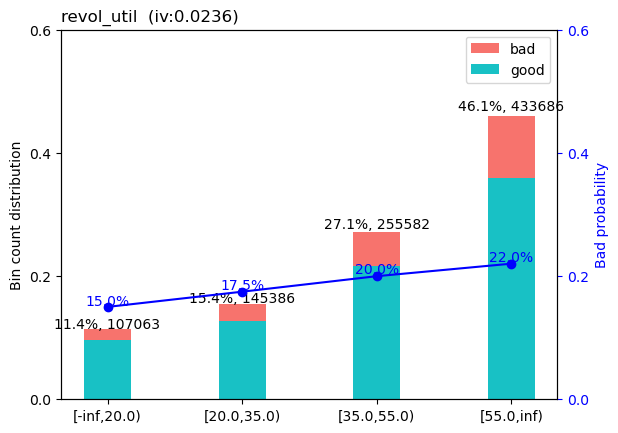

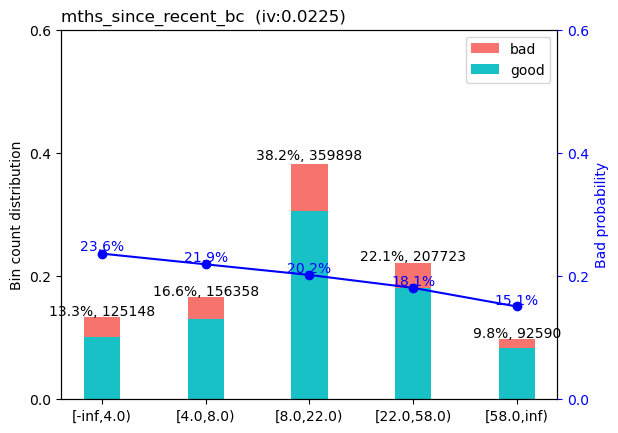

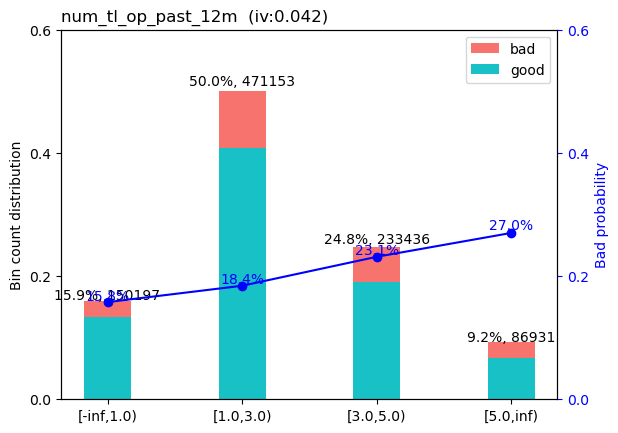

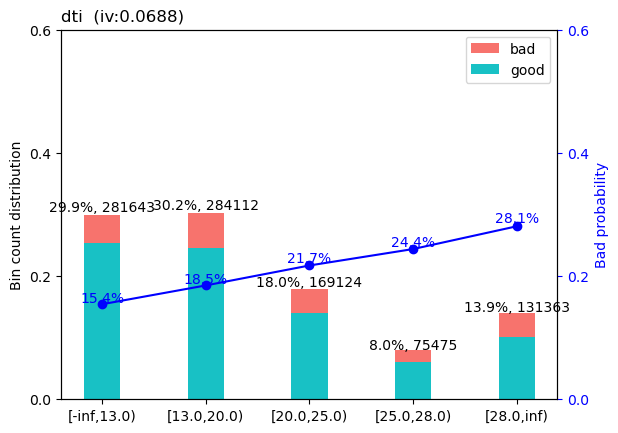

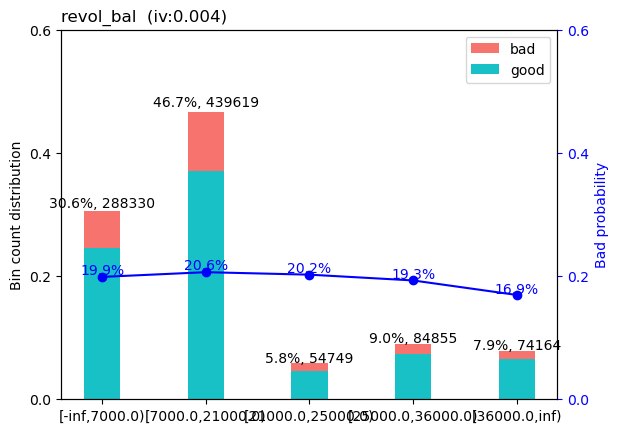

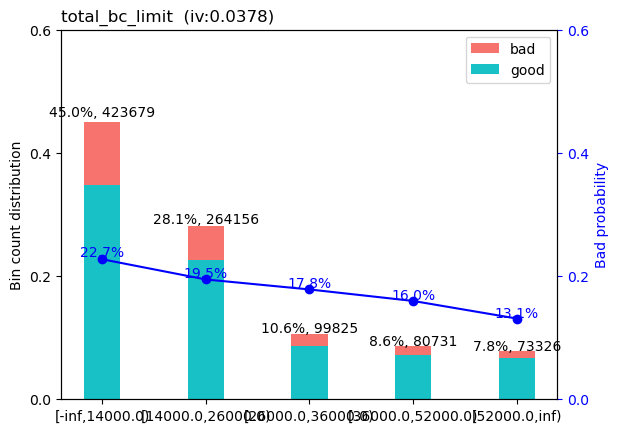

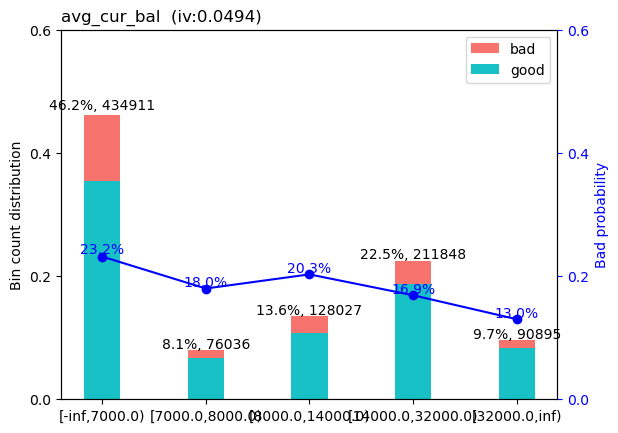

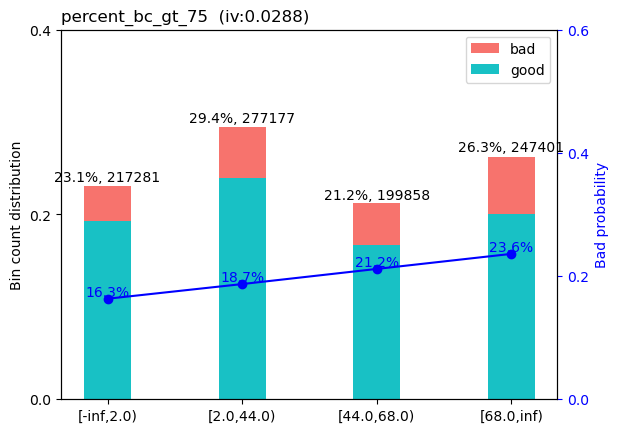

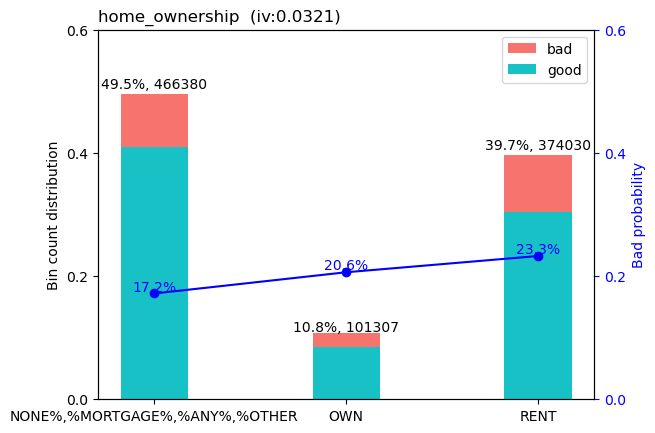

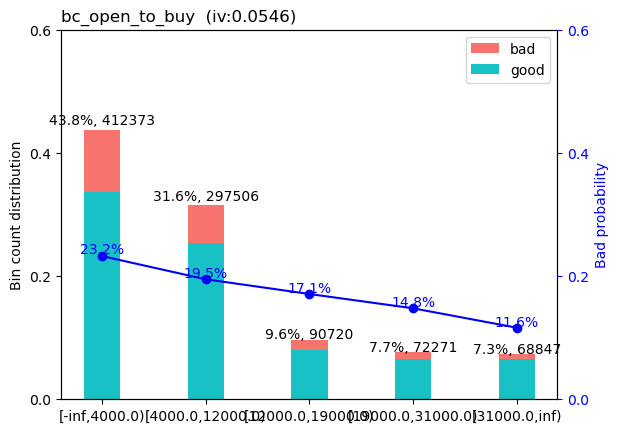

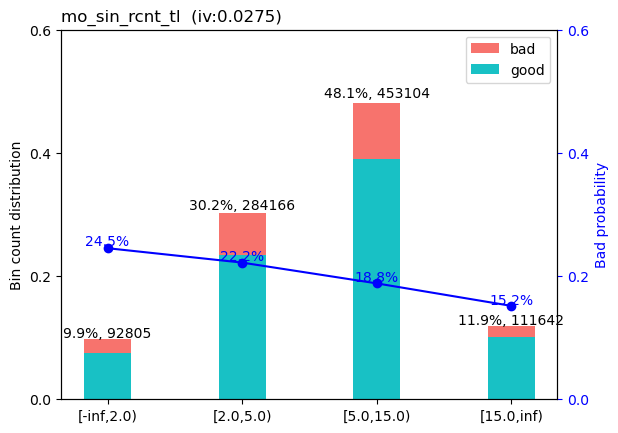

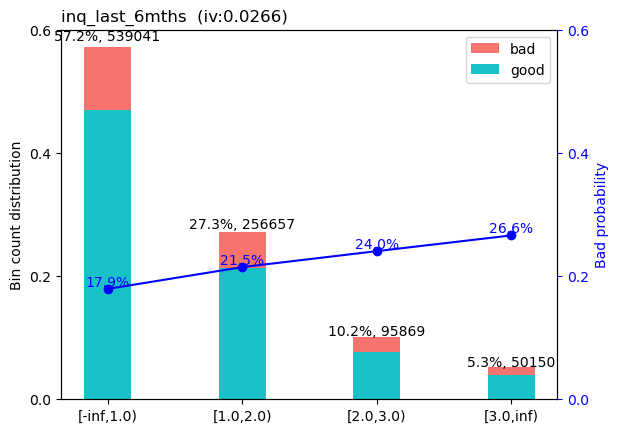

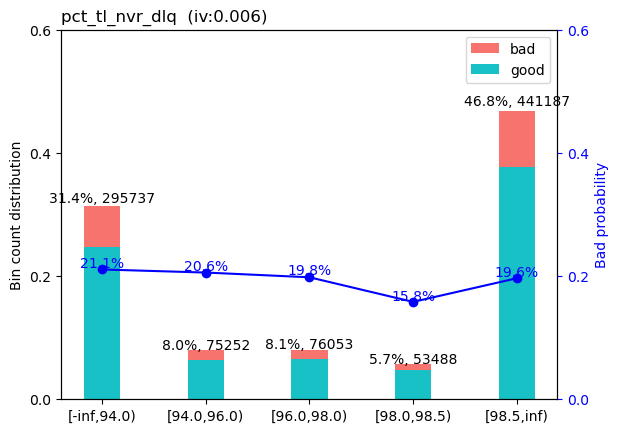

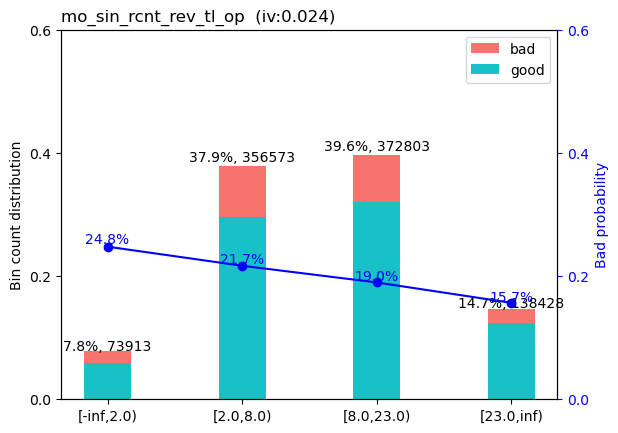

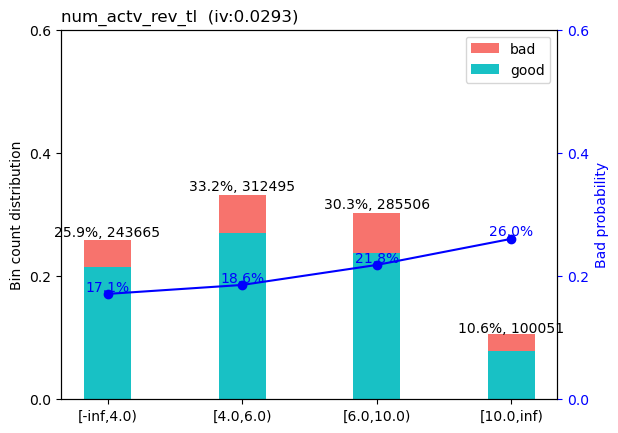

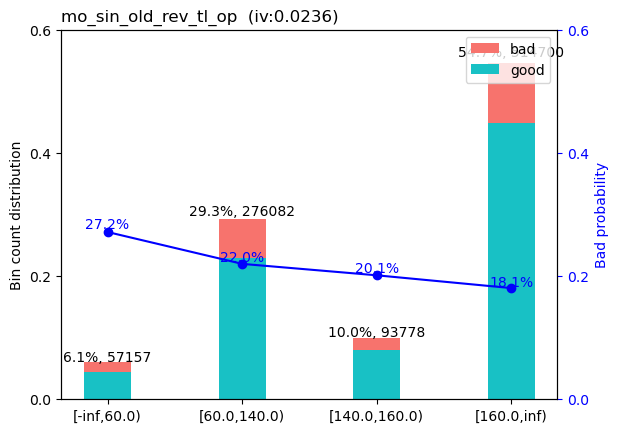

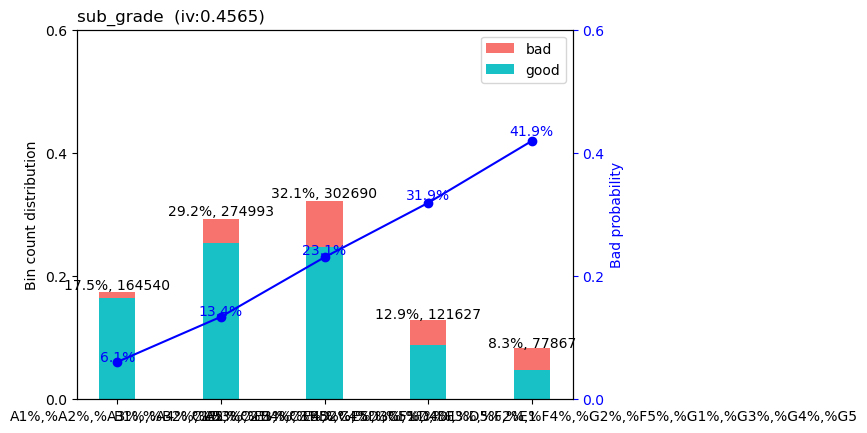

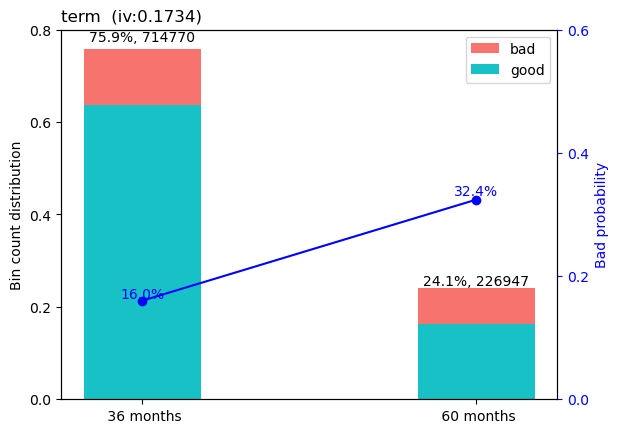

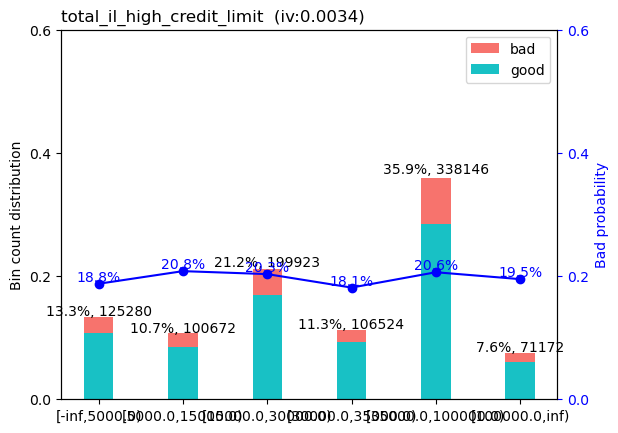

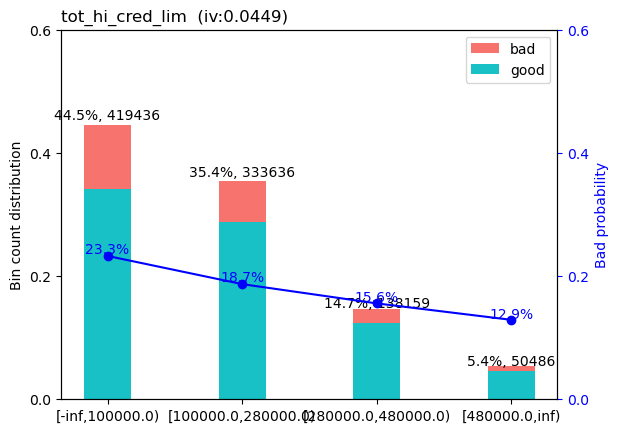

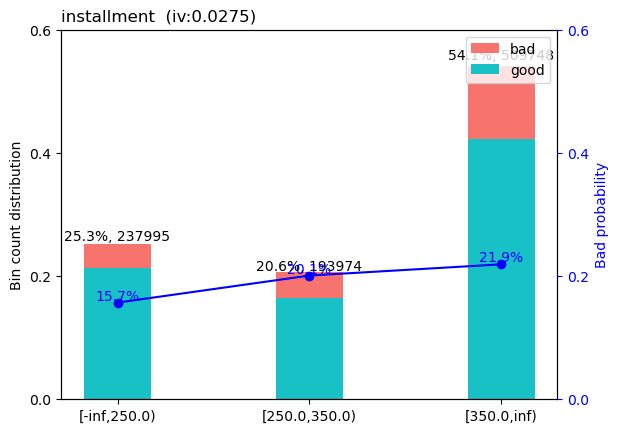

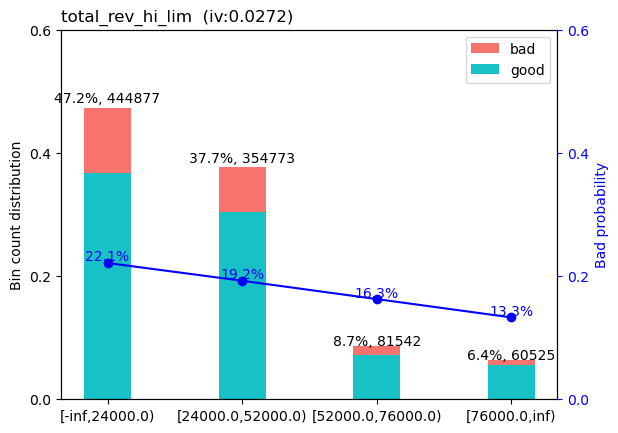

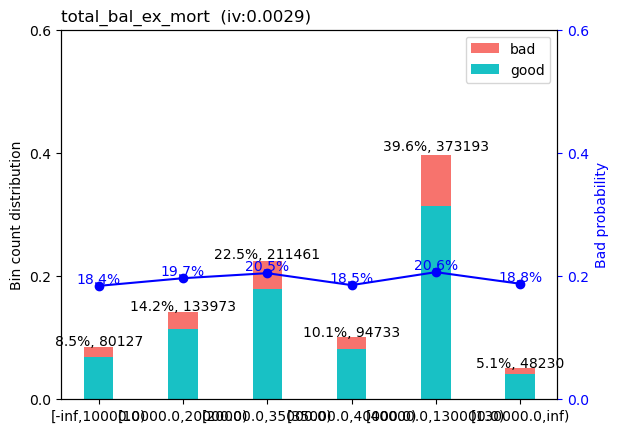

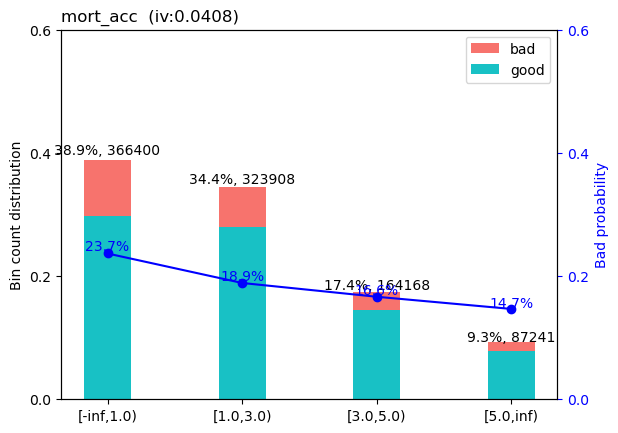

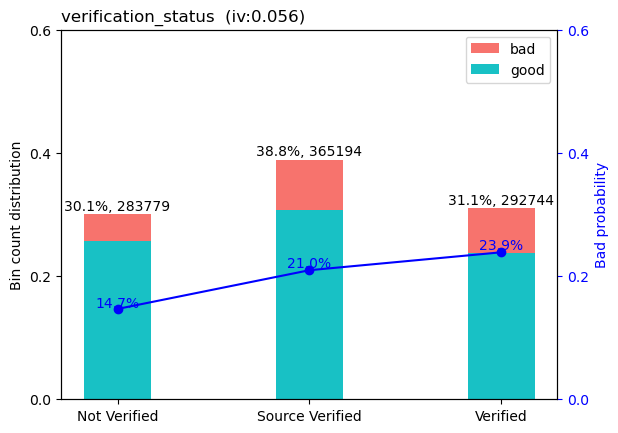

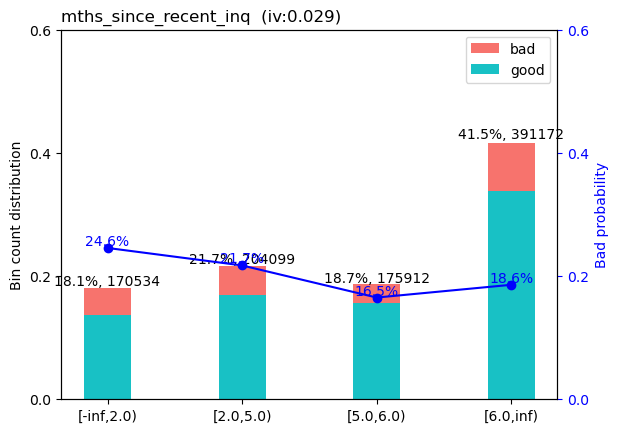

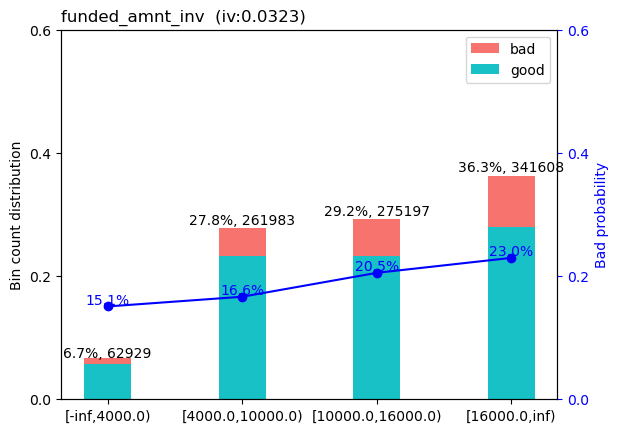

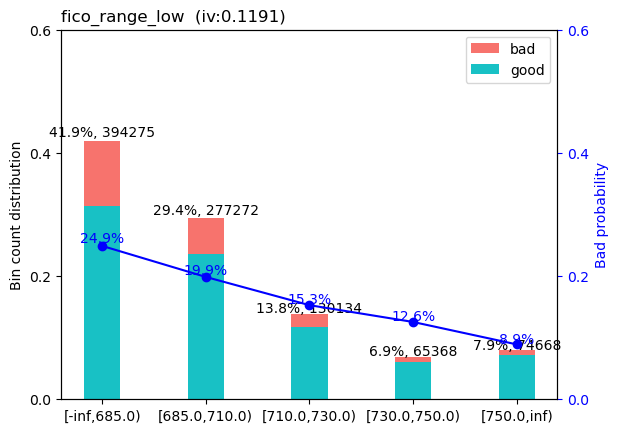

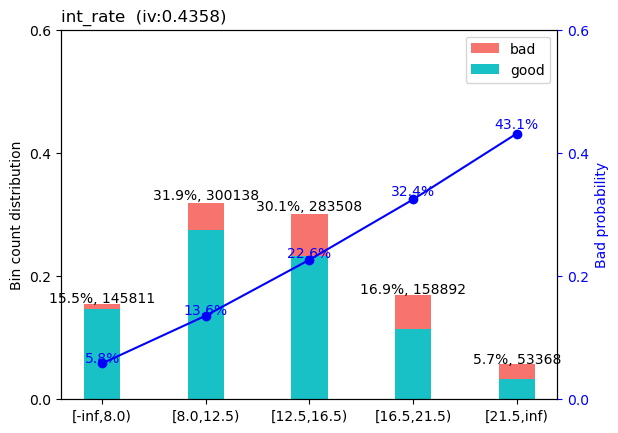

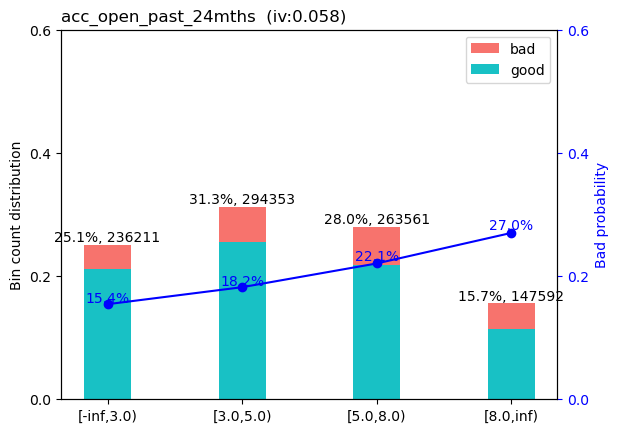

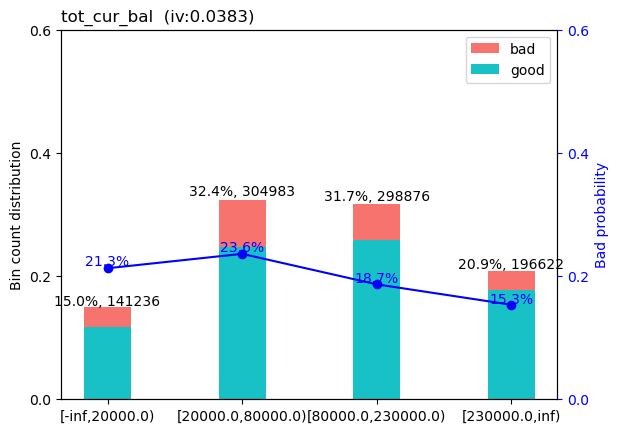

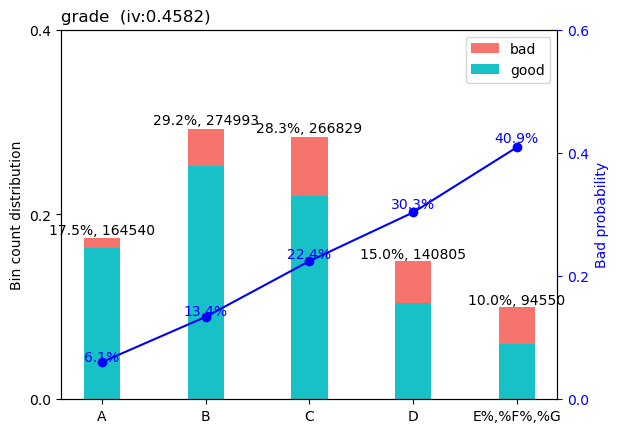

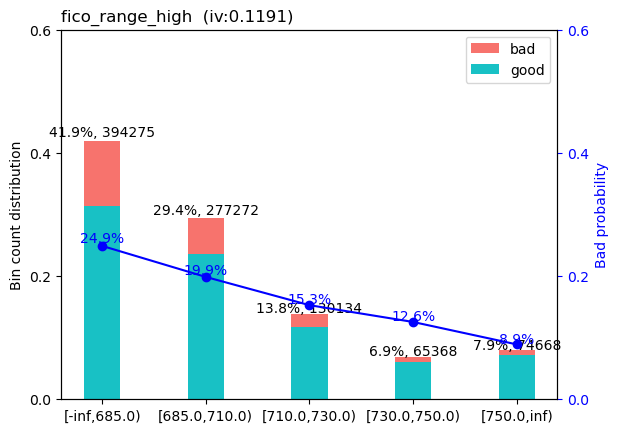

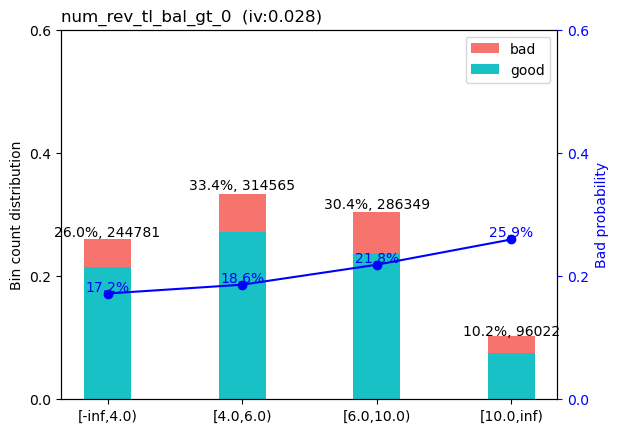

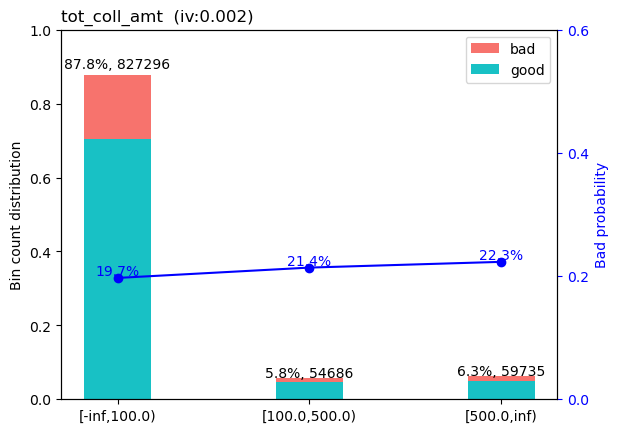

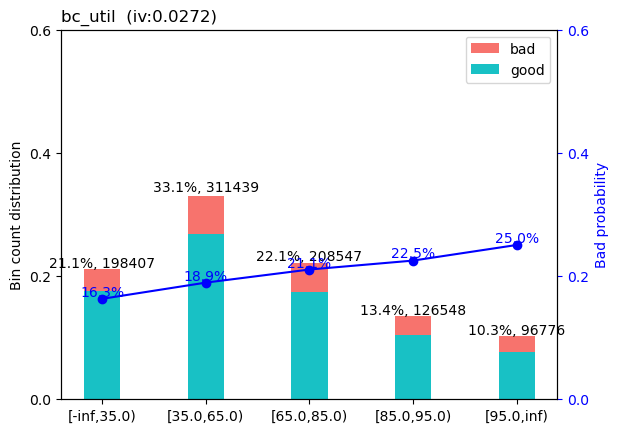

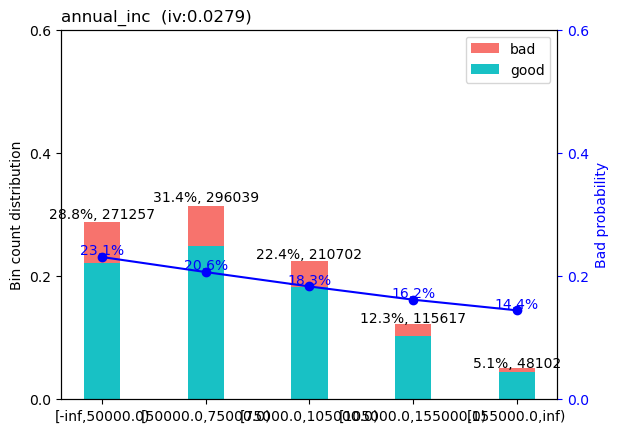

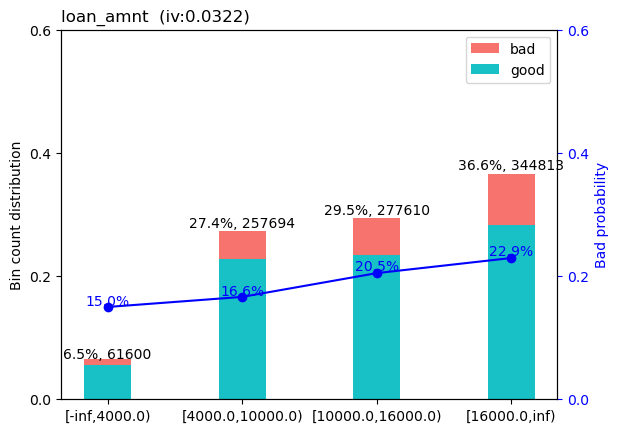

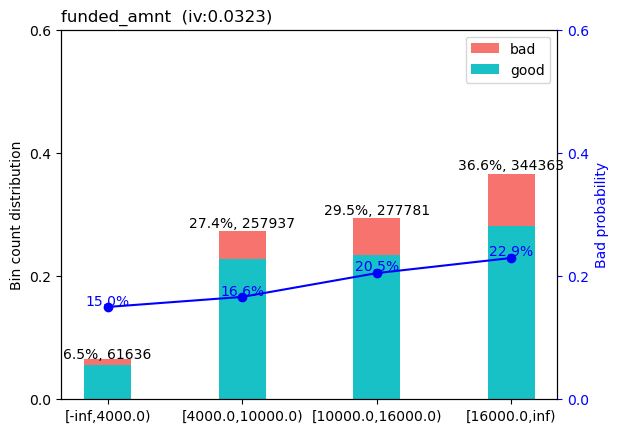

In [83]:
sc.woebin_plot(bins)

In [86]:
for col in train.columns:
    print(f"'{col}',")

'loan_amnt',
'funded_amnt',
'funded_amnt_inv',
'term',
'int_rate',
'installment',
'grade',
'sub_grade',
'home_ownership',
'annual_inc',
'verification_status',
'issue_d',
'dti',
'earliest_cr_line',
'fico_range_low',
'fico_range_high',
'inq_last_6mths',
'revol_bal',
'revol_util',
'tot_coll_amt',
'tot_cur_bal',
'total_rev_hi_lim',
'acc_open_past_24mths',
'avg_cur_bal',
'bc_open_to_buy',
'bc_util',
'mo_sin_old_rev_tl_op',
'mo_sin_rcnt_rev_tl_op',
'mo_sin_rcnt_tl',
'mort_acc',
'mths_since_recent_bc',
'mths_since_recent_inq',
'num_actv_rev_tl',
'num_rev_tl_bal_gt_0',
'num_tl_op_past_12m',
'pct_tl_nvr_dlq',
'percent_bc_gt_75',
'tot_hi_cred_lim',
'total_bal_ex_mort',
'total_bc_limit',
'total_il_high_credit_limit',
'target',


In [88]:
# Check monotonicity of WoE bins
non_monotonic = []

for var, bin_df in bins.items():
    woe_values = bin_df['woe'].values
    
    # Check if monotonically increasing
    is_increasing = all(woe_values[i] <= woe_values[i+1] 
                       for i in range(len(woe_values)-1))
    
    # Check if monotonically decreasing
    is_decreasing = all(woe_values[i] >= woe_values[i+1] 
                       for i in range(len(woe_values)-1))
    
    # If neither increasing nor decreasing — non monotonic
    if not is_increasing and not is_decreasing:
        non_monotonic.append(var)

print('Non monotonic variables:')
for var in non_monotonic:
    iv_val = iv[iv['variable'] == var]['info_value'].values
    if len(iv_val) > 0:
        print(f'{var} — IV: {round(iv_val[0], 4)}')
    else:
        print(var)

Non monotonic variables:
revol_bal — IV: 0.2655
avg_cur_bal — IV: 0.2519
pct_tl_nvr_dlq — IV: 0.0096
total_il_high_credit_limit — IV: 0.4401
total_bal_ex_mort — IV: 0.4941
mths_since_recent_inq — IV: 0.0313
tot_cur_bal — IV: 0.4931


In [90]:
cols_to_drop_woe = [
    'tot_cur_bal',
    'mths_since_recent_inq',
    'total_bal_ex_mort',
    'avg_cur_bal',
    'revol_bal',
    'pct_tl_nvr_dlq',
    'total_il_high_credit_limit'
]

train = train.drop(columns=cols_to_drop_woe, errors='ignore')
test = test.drop(columns=cols_to_drop_woe, errors='ignore')
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (941717, 35)
Test shape: (403593, 35)


In [92]:
# Remove the duplicates
duplicate_cols = [
    'grade',           # same as sub_grade
    'fico_range_high', # same as fico_range_low
    'funded_amnt',     # same as loan_amnt
    'funded_amnt_inv', # same as loan_amnt
    'installment'      # derived from loan_amnt and int_rate
]

train = train.drop(columns=duplicate_cols, errors='ignore')
test = test.drop(columns=duplicate_cols, errors='ignore')
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Train shape: (941717, 30)
Test shape: (403593, 30)


In [94]:
for var in bins:
    print(f'\n--- {var} ---')
    print(bins[var][['bin', 'count', 'badprob', 'woe']])


--- revol_util ---
           bin   count   badprob       woe
0  [-inf,20.0)  107063  0.149949 -0.346366
1  [20.0,35.0)  145386  0.174625 -0.164564
2  [35.0,55.0)  255582  0.199815  0.001181
3   [55.0,inf)  433686  0.220159  0.123896

--- mths_since_recent_bc ---
           bin   count   badprob       woe
0   [-inf,4.0)  125148  0.236408  0.216161
1    [4.0,8.0)  156358  0.219087  0.117640
2   [8.0,22.0)  359898  0.201807  0.013597
3  [22.0,58.0)  207723  0.180871 -0.121825
4   [58.0,inf)   92590  0.150643 -0.340935

--- num_tl_op_past_12m ---
          bin   count   badprob       woe
0  [-inf,1.0)  150197  0.157733 -0.286560
1   [1.0,3.0)  471153  0.184290 -0.098910
2   [3.0,5.0)  233436  0.231301  0.187656
3   [5.0,inf)   86931  0.270065  0.394341

--- dti ---
           bin   count   badprob       woe
0  [-inf,13.0)  281643  0.154291 -0.312700
1  [13.0,20.0)  284112  0.184807 -0.095475
2  [20.0,25.0)  169124  0.217196  0.106551
3  [25.0,28.0)   75475  0.243869  0.257050
4   [28.0,i

In [ ]:
print(train.columns.tolist())

In [96]:
cols_to_drop_final = [
    'tot_coll_amt',    # 88% in one bin — useless
    'issue_d',         # date column — not useful for model
    'earliest_cr_line' # date column — not useful for model
]

train = train.drop(columns=cols_to_drop_final, errors='ignore')
test = test.drop(columns=cols_to_drop_final, errors='ignore')

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print(train.columns.tolist())

Train shape: (941717, 27)
Test shape: (403593, 27)
['loan_amnt', 'term', 'int_rate', 'sub_grade', 'home_ownership', 'annual_inc', 'verification_status', 'dti', 'fico_range_low', 'inq_last_6mths', 'revol_util', 'total_rev_hi_lim', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'num_actv_rev_tl', 'num_rev_tl_bal_gt_0', 'num_tl_op_past_12m', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bc_limit', 'target']


In [98]:
corr = train.select_dtypes(include='number').drop(columns=['target']).corr()
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) > 0.7:
            high_corr_pairs.append({'var1':corr.columns[i],'var2':corr.columns[j],'correlation':round(corr.iloc[i,j],3)})
            
high_corr_df = pd.DataFrame(high_corr_pairs)
high_corr_df = high_corr_df.sort_values('correlation',ascending = False)
print(high_corr_df)


                   var1                 var2  correlation
6       num_actv_rev_tl  num_rev_tl_bal_gt_0        0.982
5               bc_util     percent_bc_gt_75        0.843
4        bc_open_to_buy       total_bc_limit        0.838
0            revol_util              bc_util        0.827
3  acc_open_past_24mths   num_tl_op_past_12m        0.754
2      total_rev_hi_lim       total_bc_limit        0.715
1            revol_util     percent_bc_gt_75        0.704


In [100]:
cols_to_drop_corr = ['num_rev_tl_bal_gt_0','percent_bc_gt_75','total_bc_limit','bc_util','num_tl_op_past_12m']
train = train.drop(columns = cols_to_drop_corr, errors = 'ignore')
test = test.drop(columns = cols_to_drop_corr,errors = 'ignore')
print('Train shape:',train.shape)
print('Test.shape:',test.shape)

Train shape: (941717, 22)
Test.shape: (403593, 22)


In [102]:
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)
print('Train WOE shape:',train_woe.shape)
print('Test WOE shape:',test_woe.shape)

[INFO] converting into woe values ...
Woe transformating on 941717 rows and 21 columns in 00:00:16
[INFO] converting into woe values ...
Train WOE shape: (941717, 22)
Test WOE shape: (403593, 22)


In [104]:
print(train_woe.head())

         target  revol_util_woe  mths_since_recent_bc_woe   dti_woe  \
670533        0        0.001181                  0.013597  0.106551   
2159594       0        0.123896                  0.013597  0.106551   
1308199       0        0.001181                 -0.340935 -0.095475   
1975729       1        0.123896                 -0.121825  0.106551   
49995         1        0.123896                 -0.340935 -0.312700   

         home_ownership_woe  bc_open_to_buy_woe  mo_sin_rcnt_tl_woe  \
670533            -0.184652            0.194119           -0.073434   
2159594           -0.184652           -0.364167           -0.073434   
1308199           -0.184652           -0.030422            0.264560   
1975729            0.194971            0.194119           -0.073434   
49995             -0.184652           -0.030422           -0.073434   

         inq_last_6mths_woe  mo_sin_rcnt_rev_tl_op_woe  num_actv_rev_tl_woe  \
670533            -0.133825                  -0.063565            -

In [106]:
from sklearn.linear_model import LogisticRegression
import numpy as np
X_train = train_woe.drop(columns = ['target'])
y_train = train_woe['target']

X_test = test_woe.drop(columns = ['target'])
y_test = test_woe['target']

lr = LogisticRegression(max_iter = 1000)
lr.fit(X_train, y_train)

print('Model built successfully!')
print('Number of variable:',len(X_train.columns))

Model built successfully!
Number of variable: 21


In [108]:
# See coefficients for each variable
coefficients = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': lr.coef_[0]
})
coefficients = coefficients.sort_values('coefficient', ascending=False)
print(coefficients)

                     variable  coefficient
20              loan_amnt_woe     0.739577
19             annual_inc_woe     0.564170
11                   term_woe     0.558450
3          home_ownership_woe     0.546452
2                     dti_woe     0.481027
8         num_actv_rev_tl_woe     0.468826
18   acc_open_past_24mths_woe     0.439263
10              sub_grade_woe     0.438921
14               mort_acc_woe     0.401028
1    mths_since_recent_bc_woe     0.387630
9    mo_sin_old_rev_tl_op_woe     0.288957
16         fico_range_low_woe     0.280287
13       total_rev_hi_lim_woe     0.272379
12        tot_hi_cred_lim_woe     0.267253
6          inq_last_6mths_woe     0.265917
15    verification_status_woe     0.264821
4          bc_open_to_buy_woe     0.221125
5          mo_sin_rcnt_tl_woe     0.188811
17               int_rate_woe     0.187109
0              revol_util_woe    -0.198554
7   mo_sin_rcnt_rev_tl_op_woe    -0.206866


In [110]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.453043
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:               941717
Model:                          Logit   Df Residuals:                   941695
Method:                           MLE   Df Model:                           21
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                 0.09370
Time:                        00:19:44   Log-Likelihood:            -4.2664e+05
converged:                       True   LL-Null:                   -4.7075e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.3909      0.003   -499.967      0.000      -1.

In [112]:
# Drop revol_util due to wrong sign
X_train = X_train.drop(columns=['revol_util_woe'])
X_test = X_test.drop(columns=['revol_util_woe'])

# Rebuild logistic regression
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train, y_train)
print('Model rebuilt successfully!')
print('Number of variables:', len(X_train.columns))

Model rebuilt successfully!
Number of variables: 20


In [114]:
coefficients2 = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': lr2.coef_[0]
})
coefficients2 = coefficients2.sort_values('coefficient', ascending=False)
print(coefficients2)

                     variable  coefficient
19              loan_amnt_woe     0.723318
18             annual_inc_woe     0.579580
10                   term_woe     0.561345
2          home_ownership_woe     0.544606
1                     dti_woe     0.466304
17   acc_open_past_24mths_woe     0.464556
7         num_actv_rev_tl_woe     0.448136
9               sub_grade_woe     0.439796
13               mort_acc_woe     0.399200
0    mths_since_recent_bc_woe     0.380777
8    mo_sin_old_rev_tl_op_woe     0.295010
12       total_rev_hi_lim_woe     0.288986
11        tot_hi_cred_lim_woe     0.281492
5          inq_last_6mths_woe     0.278204
14    verification_status_woe     0.261816
15         fico_range_low_woe     0.255176
4          mo_sin_rcnt_tl_woe     0.195289
16               int_rate_woe     0.183523
3          bc_open_to_buy_woe     0.164345
6   mo_sin_rcnt_rev_tl_op_woe    -0.202007


In [116]:
# Drop mo_sin_rcnt_rev_tl_op due to wrong sign
X_train = X_train.drop(columns=['mo_sin_rcnt_rev_tl_op_woe'])
X_test = X_test.drop(columns=['mo_sin_rcnt_rev_tl_op_woe'])

# Rebuild logistic regression
lr3 = LogisticRegression(max_iter=1000)
lr3.fit(X_train, y_train)

# Check coefficients
coefficients3 = pd.DataFrame({
    'variable': X_train.columns,
    'coefficient': lr3.coef_[0]
})
coefficients3 = coefficients3.sort_values('coefficient', ascending=False)
print(coefficients3)
print('Number of variables:', len(X_train.columns))

                    variable  coefficient
18             loan_amnt_woe     0.717630
9                   term_woe     0.560210
17            annual_inc_woe     0.556175
2         home_ownership_woe     0.538339
1                    dti_woe     0.474307
16  acc_open_past_24mths_woe     0.453091
8              sub_grade_woe     0.441770
6        num_actv_rev_tl_woe     0.429591
12              mort_acc_woe     0.402267
0   mths_since_recent_bc_woe     0.311856
7   mo_sin_old_rev_tl_op_woe     0.298278
10       tot_hi_cred_lim_woe     0.288626
11      total_rev_hi_lim_woe     0.282140
5         inq_last_6mths_woe     0.266965
13   verification_status_woe     0.256825
14        fico_range_low_woe     0.252452
15              int_rate_woe     0.183997
3         bc_open_to_buy_woe     0.169190
4         mo_sin_rcnt_tl_woe     0.115880
Number of variables: 19


In [118]:
import pickle

# Save all important objects
with open('scorecard_objects.pkl', 'wb') as f:
    pickle.dump({
        'train': train,
        'test': test,
        'train_woe': train_woe,
        'test_woe': test_woe,
        'bins': bins,
        'lr3': lr3,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }, f)

print('All objects saved successfully!')

All objects saved successfully!


In [124]:
#Scorecard Development- It will convert your logistic regression coefficient into actual points for each bin of each variable
card = sc.scorecard(bins, lr3, X_train.columns)
print(card)

{'basepoints':      variable  bin  points
0  basepoints  NaN   488.0, 'mths_since_recent_bc':                variable          bin  points
4  mths_since_recent_bc   [-inf,4.0)    -5.0
5  mths_since_recent_bc    [4.0,8.0)    -3.0
6  mths_since_recent_bc   [8.0,22.0)    -0.0
7  mths_since_recent_bc  [22.0,58.0)     3.0
8  mths_since_recent_bc   [58.0,inf)     8.0, 'dti':    variable          bin  points
13      dti  [-inf,13.0)    11.0
14      dti  [13.0,20.0)     3.0
15      dti  [20.0,25.0)    -4.0
16      dti  [25.0,28.0)    -9.0
17      dti   [28.0,inf)   -15.0, 'home_ownership':           variable                            bin  points
37  home_ownership  NONE%,%MORTGAGE%,%ANY%,%OTHER     7.0
38  home_ownership                            OWN    -2.0
39  home_ownership                           RENT    -8.0, 'bc_open_to_buy':           variable                bin  points
40  bc_open_to_buy      [-inf,4000.0)    -2.0
41  bc_open_to_buy   [4000.0,12000.0)     0.0
42  bc_open_to_buy  [1

In [126]:
# Display scorecard clearly for each variable
for var, table in card.items():
    print(f'\n{"="*50}')
    print(f'Variable: {var}')
    print(f'{"="*50}')
    print(table[['bin', 'points']].to_string(index=False))


Variable: basepoints
 bin  points
 NaN   488.0

Variable: mths_since_recent_bc
        bin  points
 [-inf,4.0)    -5.0
  [4.0,8.0)    -3.0
 [8.0,22.0)    -0.0
[22.0,58.0)     3.0
 [58.0,inf)     8.0

Variable: dti
        bin  points
[-inf,13.0)    11.0
[13.0,20.0)     3.0
[20.0,25.0)    -4.0
[25.0,28.0)    -9.0
 [28.0,inf)   -15.0

Variable: home_ownership
                          bin  points
NONE%,%MORTGAGE%,%ANY%,%OTHER     7.0
                          OWN    -2.0
                         RENT    -8.0

Variable: bc_open_to_buy
              bin  points
    [-inf,4000.0)    -2.0
 [4000.0,12000.0)     0.0
[12000.0,19000.0)     2.0
[19000.0,31000.0)     4.0
    [31000.0,inf)     8.0

Variable: mo_sin_rcnt_tl
       bin  points
[-inf,2.0)    -2.0
 [2.0,5.0)    -1.0
[5.0,15.0)     1.0
[15.0,inf)     3.0

Variable: inq_last_6mths
       bin  points
[-inf,1.0)     3.0
 [1.0,2.0)    -2.0
 [2.0,3.0)    -5.0
 [3.0,inf)    -7.0

Variable: num_actv_rev_tl
       bin  points
[-inf,4.0)     6.

In [128]:
# Apply scorecard to get actual scores for each borrower
train_score = sc.scorecard_ply(train, card)
test_score = sc.scorecard_ply(test, card)

# Check what scores look like
print('Train scores:')
print(train_score.head(10))

# Check score distribution
print('\nTrain score summary:')
print(train_score['score'].describe())

print('\nTest score summary:')
print(test_score['score'].describe())

/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


Train scores:
         score
670533   568.0
2159594  421.0
1308199  446.0
1975729  453.0
49995    601.0
1842493  541.0
537095   468.0
1614158  587.0
52511    483.0
1305495  532.0

Train score summary:
count    941717.00000
mean        502.65968
std          60.62686
min         303.00000
25%         460.00000
50%         500.00000
75%         543.00000
max         704.00000
Name: score, dtype: float64

Test score summary:
count    403593.000000
mean        502.622521
std          60.622223
min         319.000000
25%         460.000000
50%         500.000000
75%         543.000000
max         691.000000
Name: score, dtype: float64


/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


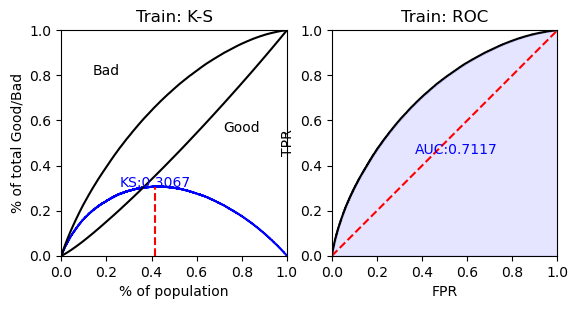

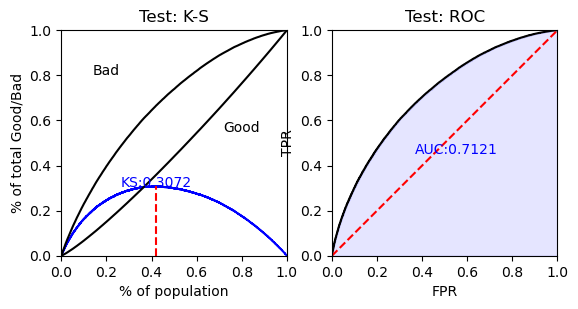

In [130]:
# Get predicted probabilities
train_pred = lr3.predict_proba(X_train)[:,1]
test_pred = lr3.predict_proba(X_test)[:,1]

# Run validation
train_perf = sc.perf_eva(y_train, train_pred, title='Train')
test_perf = sc.perf_eva(y_test, test_pred, title='Test')

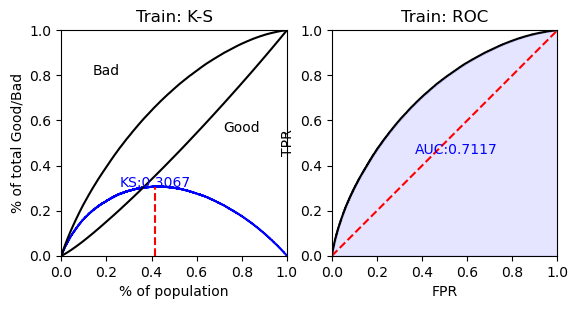

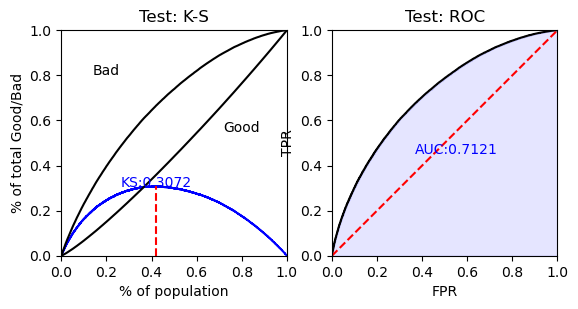

In [132]:
# Get predicted probabilities
train_pred = lr3.predict_proba(X_train)[:,1]
test_pred = lr3.predict_proba(X_test)[:,1]

# Run validation on train
train_perf = sc.perf_eva(y_train, train_pred, title='Train')

# Run validation on test
test_perf = sc.perf_eva(y_test, test_pred, title='Test')

/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:470: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt_bae = dat.groupby(['ae','bin']).size().reset_index(name='N')\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:471: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(values='N', index='bin', columns='ae').fillna(0.9)\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:511: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

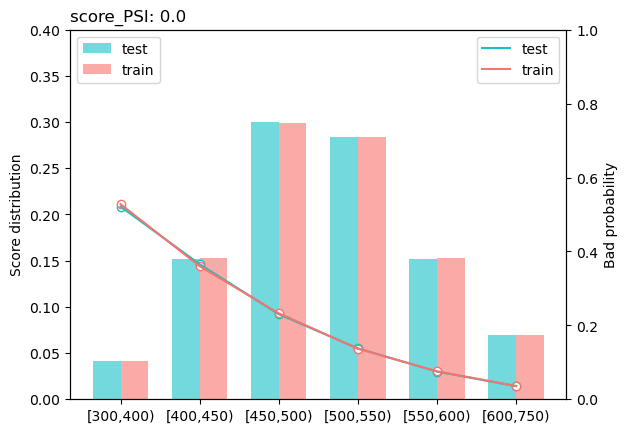

In [134]:
# PSI check
psi = sc.perf_psi(
    score={'train': train_score, 'test': test_score},
    label={'train': y_train, 'test': y_test}
)

/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:470: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt_bae = dat.groupby(['ae','bin']).size().reset_index(name='N')\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:471: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(values='N', index='bin', columns='ae').fillna(0.9)\
/opt/anaconda3/lib/python3.12/site-packages/scorecardpy/perf.py:511: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and s

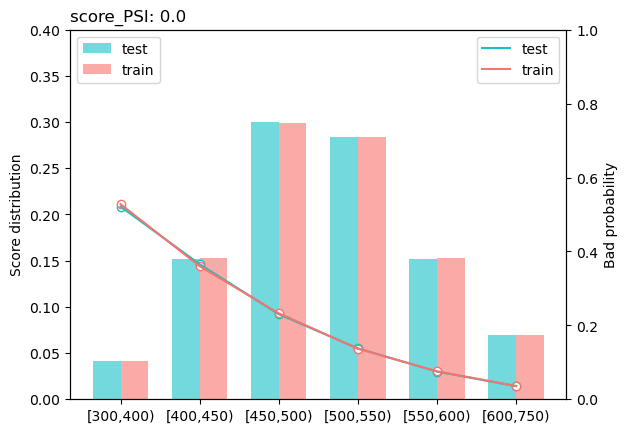

In [136]:
psi = sc.perf_psi(
    score={'train': train_score, 'test': test_score},
    label={'train': y_train, 'test': y_test}
)

In [140]:
# Correct cut off table
score_label = train_score.copy()
score_label['target'] = y_train.values

score_label = score_label.sort_values('score', ascending=False)
score_label['score_band'] = pd.cut(score_label['score'], bins=10)

cutoff_table = score_label.groupby('score_band', observed=True).agg(
    total=('target', 'count'),
    bads=('target', 'sum')
).reset_index()

cutoff_table['good'] = cutoff_table['total'] - cutoff_table['bads']
cutoff_table['bad_rate'] = (cutoff_table['bads'] / cutoff_table['total']).round(3)
cutoff_table = cutoff_table.sort_values('score_band', ascending=False)
cutoff_table['cum_approval_rate'] = (cutoff_table['total'].cumsum() / cutoff_table['total'].sum()).round(3)

print(cutoff_table[['score_band', 'total', 'bads', 'bad_rate', 'cum_approval_rate']])

         score_band   total   bads  bad_rate  cum_approval_rate
9    (663.9, 704.0]     593     11     0.019              0.001
8    (623.8, 663.9]   21623    517     0.024              0.024
7    (583.7, 623.8]   81627   4018     0.049              0.110
6    (543.6, 583.7]  130086  11289     0.087              0.248
5    (503.5, 543.6]  218416  29635     0.136              0.480
4    (463.4, 503.5]  237907  50711     0.213              0.733
3    (423.3, 463.4]  161329  49824     0.309              0.904
2    (383.2, 423.3]   70947  31066     0.438              0.980
1    (343.1, 383.2]   18437  10417     0.565              0.999
0  (302.599, 343.1]     752    503     0.669              1.000


In [142]:
# Set cut off
cutoff = 504
print(f'Cut off score: {cutoff}')
print(f'Approval rate: 73%')
print(f'Bad rate at cut off: 13.6%')
print(f'Borrowers approved: {(train_score["score"] >= cutoff).sum()}')
print(f'Borrowers declined: {(train_score["score"] < cutoff).sum()}')

Cut off score: 504
Approval rate: 73%
Bad rate at cut off: 13.6%
Borrowers approved: 452345
Borrowers declined: 489372


In [144]:
import os
print(os.getcwd())

/Users/komaljaitly
